# 03 - Embedding and subfamily clustering

### Import Libraries

In [ ]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Deep learning (for ESM-2)
try:
    import torch
    print(f"✓ PyTorch: {torch.__version__}")
    print(f"✓ CUDA available: {torch.cuda.is_available()}")
except ImportError:
    print("⚠️  PyTorch not found. Install: pip install torch")

# Plotting config
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("\n✓ All libraries loaded successfully!")

✓ PyTorch: 2.10.0+cpu
✓ CUDA available: False

✓ All libraries loaded successfully!


---
### Install ESM-2

In [45]:
# ESM (Evolutionary Scale Modeling) - Facebook Research protein language model
try:
    import esm
    print("✓ ESM already installed")
except ImportError:
    print("Installing ESM...")
    !pip install fair-esm
    import esm
    print("✓ ESM installed successfully")

✓ ESM already installed


---
### Load Data

### Data Structure:
- **Labeled data**: Sequences with known subfamily 
- **Unlabeled data**: Sequences marked as 'Unknown' 

In [ ]:
df_full = pd.read_csv('../data/processed/sequences_labeled_full.csv')

df_labeled = df_full[df_full['subfamily'] != 'Other_ClassA'].copy()
df_unlabeled = df_full[df_full['subfamily'] == 'Other_ClassA'].copy()

df_labeled['sequence'] = df_labeled['sequence'].str.upper()  
df_unlabeled['sequence'] = df_unlabeled['sequence'].str.upper()  


📂 LOADING DATA

📊 Data Summary:
   • Total sequences: 1998
   • Labeled (for training): 515
   • Unlabeled (to predict): 1483

🏷️  Subfamily Distribution (Labeled):
subfamily
Adrenergic_beta     372
Adrenergic_alpha     53
Dopamine             35
Histamine            31
Serotonin            23
Muscarinic            1
Name: count, dtype: int64

📏 Sequence Length Statistics:
count    515.000000
mean     423.990291
std       13.219264
min      413.000000
25%      414.000000
50%      419.000000
75%      430.000000
max      471.000000
Name: sequence, dtype: float64


### Data Quality Check (re-check)

In [ ]:
# Show example sequences to verify they're FULL length
print("\nSample Sequences:")
for idx, row in df_labeled.head(3).iterrows():
    seq = row['sequence']
    print(f"\n{row['subfamily']} ({len(seq)} aa):")
    print(f"   {seq[:50]}...{seq[-50:]}")
    
# Check for gaps (dashes)
has_gaps = df_labeled['sequence'].str.contains('-').sum()
if has_gaps > 0:
    print(f"\n {has_gaps} sequences contain gaps (-)")
    print("   Removing gaps before embedding generation...")
    df_labeled['sequence'] = df_labeled['sequence'].str.replace('-', '')
    df_unlabeled['sequence'] = df_unlabeled['sequence'].str.replace('-', '')


🔬 Sample Sequences:

Adrenergic_beta (413 aa):
   MGQPGNGSAFLLAPNGSHAPDHDVTQERDEVWVVGMGIVMSLIVLAIVFG...SGYHVEQEKENKLLCEDLPGTEDFVGHQGTVPSDNIDSQGRNCSTNDSLL

Adrenergic_beta (416 aa):
   MGQPGNSSDFLLASNGSHAPDHNVTQERDEAWVVGMAIVMSLIVLAIVFG...SGYHLGQEKESKLLCEEPPGTEDFVNCQGTVPSDSIDSQGRNCSTNDSLL

Adrenergic_beta (418 aa):
   MGQPGNDSDFLLAPNGSQAPGHDITQERDEAWVVGMAMVMSLIVLATVFG...SGCHLGQEKESELLCEDPPGMEGFVNCQGTVPSDSIDSQGRNCSTNDSLL

⚠️  497 sequences contain gaps (-)
   Removing gaps before embedding generation...


---
### Load ESM-2 Model

### What is ESM-2?
- **Protein language model** trained on 65 million protein sequences
- Converts protein sequences → **meaningful numerical vectors** (embeddings)
- Similar to how GPT understands text, ESM-2 understands proteins

### Model Size:
- Using **ESM-2 650M** (650 million parameters)
- Embedding dimension: **1280** numbers per sequence
- Good balance of accuracy vs speed

In [ ]:
print(" LOADING ESM-2 MODEL")
print("="*80)

import torch
import esm

print("\nDownloading ESM-2 650M model...")

# Load pre-trained model
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()  # Set to evaluation mode (disable dropout)

# Use GPU if available (much faster!)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"✓ Model loaded successfully")
print(f"   • Device: {device}")
print(f"   • Embedding dimension: {model.embed_dim}")
print(f"   • Number of layers: {model.num_layers}")
print(f"   • Max sequence length: 1024 amino acids")

🤖 LOADING ESM-2 MODEL

(First time only - downloads ~2.5 GB)

✓ Model loaded successfully
   • Device: cpu
   • Embedding dimension: 1280
   • Number of layers: 33
   • Max sequence length: 1024 amino acids


---
### Define Embedding Function

### How it works:
1. **Input**: Protein sequence (string of amino acids)
2. **Process**: Feed through ESM-2's 33 layers
3. **Output**: 1280-dimensional vector (embedding)
4. **Pool**: Average all positions → single vector per sequence

In [55]:
def get_embedding(sequence, model, batch_converter, device, verbose=False):
    """
    Generate ESM-2 embedding for a protein sequence.
    
    Args:
        sequence (str): Protein sequence (amino acids)
        model: ESM-2 model
        batch_converter: ESM batch converter
        device: torch device (cuda/cpu)
        verbose (bool): Print debug info
    
    Returns:
        numpy array: 1280-dimensional embedding vector
    
    Raises:
        ValueError: If sequence is too short or invalid
    """
    # Validate sequence
    if len(sequence) < 10:
        raise ValueError(f"Sequence too short ({len(sequence)} aa)")
    
    # Remove gaps and invalid characters
    sequence = sequence.replace('-', '').replace('*', '')
    
    # Truncate if too long (ESM-2 max = 1024)
    if len(sequence) > 1022:  # Leave room for special tokens
        if verbose:
            print(f"   Truncating sequence from {len(sequence)} → 1022 aa")
        sequence = sequence[:1022]
    
    # Prepare data
    data = [("protein", sequence)]
    batch_labels, batch_strs, batch_tokens = batch_converter(data)
    batch_tokens = batch_tokens.to(device)
    
    # Generate embeddings (no gradient calculation needed)
    with torch.no_grad():
        results = model(batch_tokens, repr_layers=[33])  # Last layer
        embeddings = results["representations"][33]
    
    # Mean pooling (exclude special start/end tokens)
    # Shape: [batch=1, length, embed_dim=1280] → [1280]
    embedding = embeddings[0, 1:-1].mean(dim=0)
    
    return embedding.cpu().numpy()

print("✓ Embedding function defined")
print("\n📝 Function signature:")
print("   Input:  Protein sequence (str)")
print("   Output: 1280-dimensional vector (numpy array)")

✓ Embedding function defined

📝 Function signature:
   Input:  Protein sequence (str)
   Output: 1280-dimensional vector (numpy array)


---
### Generate Embeddings

In [ ]:
n_total = len(df_labeled)
print(f"\n  Processing {n_total} labeled sequences...")
print(f"   Estimated time: ~{n_total * 5 // 60} minutes on CPU\n")

# Storage
embeddings_list = []
valid_indices = []
failed_count = 0
failed_reasons = {}

# Progress tracking
for i, (idx, row) in enumerate(df_labeled.iterrows()):
    try:
        # Generate embedding
        sequence = row['sequence']
        embedding = get_embedding(sequence, model, batch_converter, device)
        
        # Save
        embeddings_list.append(embedding)
        valid_indices.append(idx)
        
        # Progress update
        if (i + 1) % 20 == 0 or (i + 1) == n_total:
            print(f"   Processed {i + 1}/{n_total} sequences")
        
    except Exception as e:
        failed_count += 1
        reason = str(e)[:30]
        failed_reasons[reason] = failed_reasons.get(reason, 0) + 1
        
        if failed_count <= 5:  # Show first 5 errors
            print(f"\n  Failed #{failed_count}: {row.get('id', idx)}")
            print(f"   Reason: {reason}")
            print(f"   Sequence length: {len(row['sequence'])} aa")

# Convert to array
embeddings_array = np.array(embeddings_list)

# Filter dataframe
df_labeled_valid = df_labeled.loc[valid_indices].reset_index(drop=True)

# Results
print(f"\n" + "="*80)
print(" EMBEDDING GENERATION COMPLETE")
print("="*80)
print(f"   • Successful: {len(embeddings_list)} / {n_total} ({len(embeddings_list)/n_total*100:.1f}%)")
print(f"   • Failed: {failed_count}")
print(f"   • Embedding shape: {embeddings_array.shape}")

if failed_reasons:
    print(f"\n Failure reasons:")
    for reason, count in sorted(failed_reasons.items(), key=lambda x: -x[1]):
        print(f"   • {reason}: {count} sequences")

# Check class distribution after embedding
print(f"\n Valid Sequences by Subfamily:")
print(df_labeled_valid['subfamily'].value_counts())

🔄 GENERATING EMBEDDINGS - LABELED DATA

📊 Processing 515 labeled sequences...
   Estimated time: ~42 minutes on CPU

   Processed 20/515 sequences
   Processed 40/515 sequences
   Processed 60/515 sequences
   Processed 80/515 sequences
   Processed 100/515 sequences
   Processed 120/515 sequences
   Processed 140/515 sequences
   Processed 160/515 sequences
   Processed 180/515 sequences
   Processed 200/515 sequences
   Processed 220/515 sequences
   Processed 240/515 sequences
   Processed 260/515 sequences
   Processed 280/515 sequences
   Processed 300/515 sequences
   Processed 320/515 sequences
   Processed 340/515 sequences
   Processed 360/515 sequences
   Processed 380/515 sequences
   Processed 400/515 sequences
   Processed 420/515 sequences
   Processed 440/515 sequences
   Processed 460/515 sequences
   Processed 480/515 sequences
   Processed 500/515 sequences
   Processed 515/515 sequences

✅ EMBEDDING GENERATION COMPLETE
   • Successful: 515 / 515 (100.0%)
   • Failed:

In [ ]:
n_total = len(df_unlabeled)
print(f"\n Processing {n_total} unlabeled sequences...\n")

embeddings_unlabeled = []
valid_unlabeled_indices = []
failed_unlabeled = 0

for i, (idx, row) in enumerate(df_unlabeled.iterrows()):
    try:
        sequence = row['sequence']
        embedding = get_embedding(sequence, model, batch_converter, device)
        
        embeddings_unlabeled.append(embedding)
        valid_unlabeled_indices.append(idx)
        
        if (i + 1) % 50 == 0 or (i + 1) == n_total:
            print(f"   Processed {i + 1}/{n_total} sequences")
        
    except Exception as e:
        failed_unlabeled += 1
        if failed_unlabeled <= 3:
            print(f"\n   Failed: {row.get('id', idx)} - {str(e)[:30]}")

embeddings_unlabeled_array = np.array(embeddings_unlabeled)
df_unlabeled_valid = df_unlabeled.loc[valid_unlabeled_indices].reset_index(drop=True)

print(f"\n Complete")
print(f"   • Successful: {len(embeddings_unlabeled)} / {n_total}")
print(f"   • Failed: {failed_unlabeled}")
print(f"   • Shape: {embeddings_unlabeled_array.shape}")

🔄 GENERATING EMBEDDINGS - UNLABELED DATA

📊 Processing 1483 unlabeled sequences...

   Processed 50/1483 sequences
   Processed 100/1483 sequences
   Processed 150/1483 sequences
   Processed 200/1483 sequences
   Processed 250/1483 sequences
   Processed 300/1483 sequences
   Processed 350/1483 sequences
   Processed 400/1483 sequences
   Processed 450/1483 sequences
   Processed 500/1483 sequences
   Processed 550/1483 sequences
   Processed 600/1483 sequences
   Processed 650/1483 sequences
   Processed 700/1483 sequences
   Processed 750/1483 sequences
   Processed 800/1483 sequences
   Processed 850/1483 sequences
   Processed 900/1483 sequences
   Processed 950/1483 sequences
   Processed 1000/1483 sequences
   Processed 1050/1483 sequences
   Processed 1100/1483 sequences
   Processed 1150/1483 sequences
   Processed 1200/1483 sequences
   Processed 1250/1483 sequences
   Processed 1300/1483 sequences
   Processed 1350/1483 sequences
   Processed 1400/1483 sequences
   Processed

---
### Train Classifier

### Random Forest Classifier:
- **Input**: 1280-dimensional embeddings
- **Output**: Subfamily prediction

In [ ]:
print(" TRAINING CLASSIFIER")
print("="*80)

# 1. Count occurrences
class_counts = df_labeled_valid['subfamily'].value_counts()

# 2. Identify classes with at least 2 members
valid_classes = class_counts[class_counts >= 2].index

# 3. Filter the dataframe
df_filtered = df_labeled_valid[df_labeled_valid['subfamily'].isin(valid_classes)].copy()

# 4. Re-prepare your X and y from the filtered dataframe
# Note: Ensure your embeddings_array is filtered to match the same indices
X = embeddings_array[df_filtered.index] 
y = df_filtered['subfamily'].values

# Now proceed with LabelEncoder and train_test_split
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# # Prepare features (X) and labels (y)
# X = embeddings_array
# y = df_labeled_valid['subfamily'].values

# # Encode labels to numbers
# le = LabelEncoder()
# y_encoded = le.fit_transform(y)

print(f"\n Training Data:")
print(f"   • Features (X): {X.shape}")
print(f"   • Labels (y): {y.shape}")
print(f"   • Classes: {list(le.classes_)}")

# Class distribution
print(f"\n Class Distribution:")
unique, counts = np.unique(y_encoded, return_counts=True)
for cls, count in zip(le.classes_, counts):
    print(f"   • {cls}: {count} sequences ({count/len(y)*100:.1f}%)")

# Check for class imbalance
max_count = counts.max()
min_count = counts.min()
imbalance_ratio = max_count / min_count
if imbalance_ratio > 3:
    print(f"\n Class imbalance detected! Ratio: {imbalance_ratio:.1f}:1")
    print("   Using balanced class weights to compensate.")



# Train/test split (stratified to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\n Split:")
print(f"   • Training: {len(X_train)} sequences")
print(f"   • Testing: {len(X_test)} sequences")

# Train Random Forest with class balancing
print(f"\n Training Random Forest...")
rf_clf = RandomForestClassifier(
    n_estimators=100,          # 100 decision trees
    random_state=42,           # Reproducibility
    n_jobs=-1,                 # Use all CPU cores
    class_weight='balanced',   # Balance classes!
    max_depth=20,              # Limit tree depth
    min_samples_split=5,       # Min samples to split node
    min_samples_leaf=2         # Min samples in leaf
)

rf_clf.fit(X_train, y_train)

# Evaluate
y_pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n Training Complete!")
print(f"   • Test Accuracy: {accuracy*100:.2f}%")

🎯 TRAINING CLASSIFIER

📊 Training Data:
   • Features (X): (514, 1280)
   • Labels (y): (514,)
   • Classes: ['Adrenergic_alpha', 'Adrenergic_beta', 'Dopamine', 'Histamine', 'Serotonin']

🏷️  Class Distribution:
   • Adrenergic_alpha: 53 sequences (10.3%)
   • Adrenergic_beta: 372 sequences (72.4%)
   • Dopamine: 35 sequences (6.8%)
   • Histamine: 31 sequences (6.0%)
   • Serotonin: 23 sequences (4.5%)

⚠️  Class imbalance detected! Ratio: 16.2:1
   Using balanced class weights to compensate.

📊 Split:
   • Training: 411 sequences
   • Testing: 103 sequences

🌲 Training Random Forest...

✅ Training Complete!
   • Test Accuracy: 96.12%


📊 CLASSIFICATION REPORT

                  precision    recall  f1-score   support

Adrenergic_alpha       1.00      0.82      0.90        11
 Adrenergic_beta       0.95      1.00      0.97        74
        Dopamine       1.00      1.00      1.00         7
       Histamine       1.00      0.83      0.91         6
       Serotonin       1.00      0.80      0.89         5

        accuracy                           0.96       103
       macro avg       0.99      0.89      0.93       103
    weighted avg       0.96      0.96      0.96       103



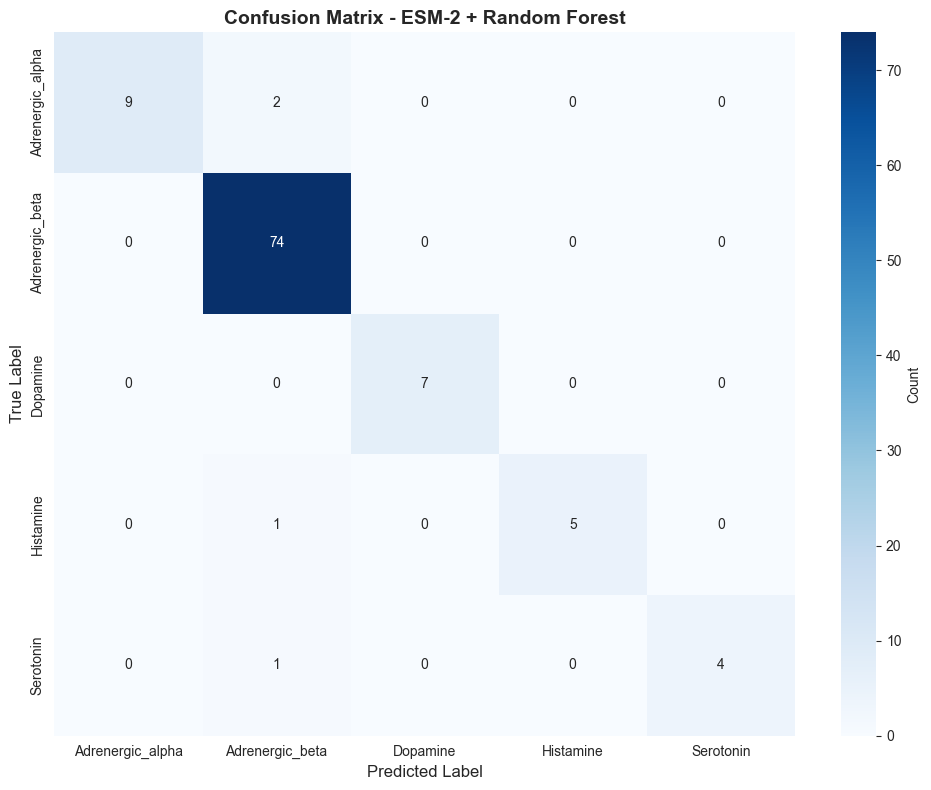


💾 Saved: ../results/figures/confusion_matrix.png

🔍 Top 10 Most Important Embedding Dimensions:
   1. Dimension 34: 0.0142
   2. Dimension 1120: 0.0134
   3. Dimension 1094: 0.0115
   4. Dimension 385: 0.0110
   5. Dimension 1115: 0.0106
   6. Dimension 849: 0.0101
   7. Dimension 990: 0.0099
   8. Dimension 1148: 0.0099
   9. Dimension 354: 0.0099
   10. Dimension 501: 0.0098


In [ ]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - ESM-2 + Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()

# Save
import os
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Saved: ../results/figures/confusion_matrix.png")

# Feature importance (which embedding dimensions matter most?)
print(f"\n Top 10 Most Important Embedding Dimensions:")
importances = rf_clf.feature_importances_
top_indices = np.argsort(importances)[-10:][::-1]
for i, idx in enumerate(top_indices, 1):
    print(f"   {i}. Dimension {idx}: {importances[idx]:.4f}")

### PREDICT SUBFAMILIES


In [ ]:
print(" PREDICTING SUBFAMILIES")
print("="*80)

# Get predictions
y_pred_unlabeled = rf_clf.predict(embeddings_unlabeled_array)
y_pred_proba = rf_clf.predict_proba(embeddings_unlabeled_array)

# Convert back to subfamily names
predicted_subfamilies = le.inverse_transform(y_pred_unlabeled)

# Add to dataframe
df_unlabeled_valid['predicted_subfamily'] = predicted_subfamilies
df_unlabeled_valid['prediction_confidence'] = y_pred_proba.max(axis=1)

# Add probability for each class
for i, class_name in enumerate(le.classes_):
    df_unlabeled_valid[f'prob_{class_name}'] = y_pred_proba[:, i]

print(f"\n Predictions Complete: {len(df_unlabeled_valid)} sequences")

# Distribution
print(f"\n Predicted Subfamily Distribution:")
pred_counts = df_unlabeled_valid['predicted_subfamily'].value_counts()
for subfamily, count in pred_counts.items():
    pct = count / len(df_unlabeled_valid) * 100
    print(f"   • {subfamily}: {count} ({pct:.1f}%)")

# Confidence statistics
print(f"\n Prediction Confidence:")
print(f"   • Mean: {df_unlabeled_valid['prediction_confidence'].mean():.3f}")
print(f"   • Median: {df_unlabeled_valid['prediction_confidence'].median():.3f}")
print(f"   • Min: {df_unlabeled_valid['prediction_confidence'].min():.3f}")
print(f"   • Max: {df_unlabeled_valid['prediction_confidence'].max():.3f}")

# High confidence predictions
high_conf = (df_unlabeled_valid['prediction_confidence'] > 0.8).sum()
print(f"\n High confidence (>80%): {high_conf} / {len(df_unlabeled_valid)} ({high_conf/len(df_unlabeled_valid)*100:.1f}%)")

🎯 PREDICTING SUBFAMILIES

✅ Predictions Complete: 1483 sequences

📊 Predicted Subfamily Distribution:
   • Adrenergic_beta: 940 (63.4%)
   • Serotonin: 216 (14.6%)
   • Adrenergic_alpha: 212 (14.3%)
   • Dopamine: 71 (4.8%)
   • Histamine: 44 (3.0%)

📈 Prediction Confidence:
   • Mean: 0.590
   • Median: 0.514
   • Min: 0.237
   • Max: 1.000

✅ High confidence (>80%): 420 / 1483 (28.3%)


---
### Visualize Predictions

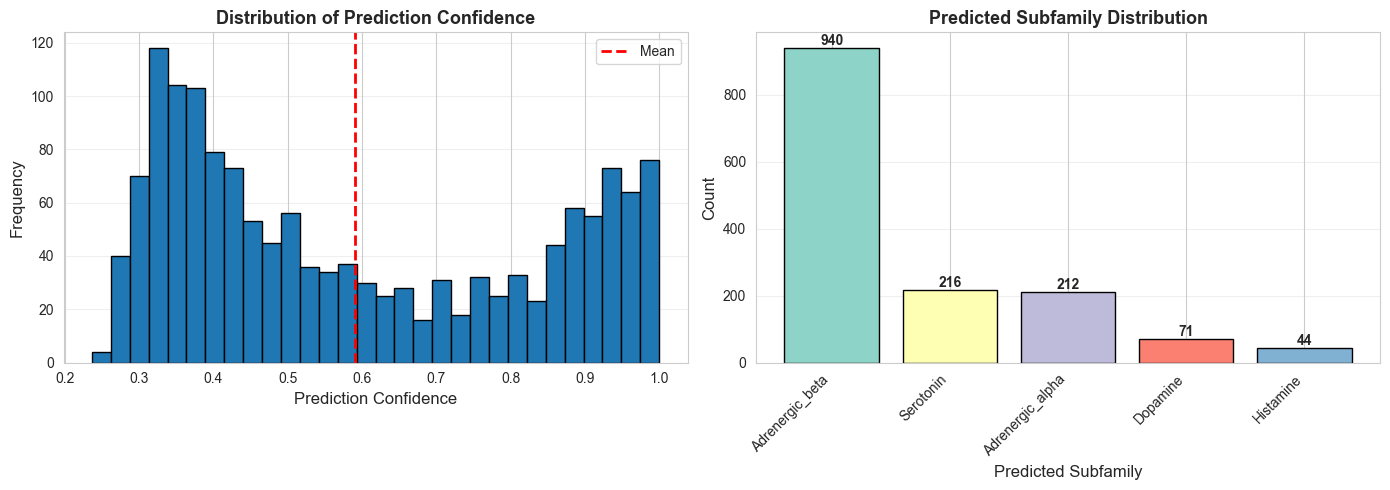


💾 Saved: ../results/figures/prediction_analysis.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence distribution
axes[0].hist(df_unlabeled_valid['prediction_confidence'], bins=30, edgecolor='black')
axes[0].axvline(df_unlabeled_valid['prediction_confidence'].mean(), 
                color='red', linestyle='--', label='Mean', linewidth=2)
axes[0].set_xlabel('Prediction Confidence', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Prediction Confidence', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Predicted classes
pred_counts = df_unlabeled_valid['predicted_subfamily'].value_counts()
colors = plt.cm.Set3(range(len(pred_counts)))
bars = axes[1].bar(range(len(pred_counts)), pred_counts.values, color=colors, edgecolor='black')
axes[1].set_xticks(range(len(pred_counts)))
axes[1].set_xticklabels(pred_counts.index, rotation=45, ha='right')
axes[1].set_xlabel('Predicted Subfamily', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Predicted Subfamily Distribution', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/prediction_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---
### Save Results

In [ ]:
import joblib
import json

# Create directories
os.makedirs('../results', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# 1. Save predictions
output_file = '../results/predicted_sequences.csv'
df_unlabeled_valid.to_csv(output_file, index=False)
print(f"\n Predictions: {output_file}")

# 2. Save model
model_file = '../models/random_forest_classifier.pkl'
joblib.dump(rf_clf, model_file)
print(f" Model: {model_file}")

# 3. Save label encoder
encoder_file = '../models/label_encoder.pkl'
joblib.dump(le, encoder_file)
print(f" Encoder: {encoder_file}")

# 4. Save embeddings
np.save('../data/processed/embeddings_labeled.npy', embeddings_array)
np.save('../data/processed/embeddings_unlabeled.npy', embeddings_unlabeled_array)
print(f" Embeddings: ../data/processed/embeddings_*.npy")


💾 SAVING RESULTS

✅ Predictions: ../results/predicted_sequences.csv
✅ Model: ../models/random_forest_classifier.pkl
✅ Encoder: ../models/label_encoder.pkl
✅ Embeddings: ../data/processed/embeddings_*.npy
✅ Summary: ../results/prediction_summary.json

🎉 PHASE 5 COMPLETE!

📊 Final Results:
   • Test Accuracy: 96.12%
   • Sequences Predicted: 1483
   • Avg Confidence: 0.590

📂 Output Files:
   • ../results/predicted_sequences.csv
   • ../models/random_forest_classifier.pkl
   • ../results/prediction_summary.json
